# Notebook 02 — Baseline Experiments with SageMaker Serverless MLflow App

**Module:** ITI113 Machine Learning & Operations  
**Focus Area:** B — Model Development + C — MLOps (Experiment Tracking)  
**Estimated Runtime:** 5–10 minutes

---

## What this notebook does

This is the AWS-native version of Notebook 02. It uses the **SageMaker MLflow App / Serverless MLflow** created in `01A_setup_sagemaker_mlflow_app_with_team_tags.ipynb`.

1. Connects to the SageMaker MLflow App instead of Databricks MLflow
2. Logistic Regression baseline — logs params, metrics, plots, and model artifacts to MLflow
3. Random Forest baseline — logs params, metrics, feature importance, and model artifacts
4. Hyperparameter tuning with nested child runs
5. Programmatic run comparison and best-model selection
6. Saves `best_model.json` for hand-off to later notebooks

## Expected setup from Notebook 01

Notebook 01 should have created an MLflow App and saved a local config file:

```text
mlflow_app_config_<team_id>.json
mlflow_app_config_<team_id>_<student_id>.json
```

Example Team 40 App from Notebook 01A:

```text
arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-L5IMA5YSBDTY
```

The training data still comes from the same team S3 prefix. Notebook 02 also validates that the selected MLflow App is tagged with the same TeamId before logging.


In [1]:
# After running this cell, restart the kernel before continuing if packages were upgraded.
%pip install --quiet --upgrade "sagemaker>=2,<3" boto3 botocore

Note: you may need to restart the kernel to use updated packages.


In [2]:
# SageMaker MLflow App support.
%pip install --quiet --upgrade mlflow sagemaker-mlflow

Note: you may need to restart the kernel to use updated packages.


## 0. Configuration

In [3]:
import os
import json
from pathlib import Path

import boto3
import sagemaker

session = sagemaker.Session()
role = sagemaker.get_execution_role()

# ============================================================
# Student / team settings
# ============================================================
TEAM_ID = "team07"
STUDENT_ID = "s703"   # Change to your own student id, e.g. s4001, s4002, s4003

COURSE = "ITI113"
SEMESTER = "26S1"
PROJECT_NAME = "heart-disease"
REGION = "ap-southeast-1"

BUCKET = "nyp-26s1-iti113"
PREFIX = f"iti113/{TEAM_ID}/data/{PROJECT_NAME}"

# ============================================================
# MLflow App config
# ------------------------------------------------------------
# Preferred:
# 1. Team-level config copied/shared from Notebook 01A:
#       mlflow_app_config_team40.json
# 2. Student-specific config from Notebook 01A:
#       mlflow_app_config_team40_s4002.json
# 3. Any local config matching this team:
#       mlflow_app_config_team40_*.json
#
# Important:
# Do not use another team's MLflow ARN. With team-level IAM
# restriction, wrong-team access should fail with 403.
# ============================================================

TEAM_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}.json")
STUDENT_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}_{STUDENT_ID}.json")

config_candidates = [
    TEAM_CONFIG_FILE,
    STUDENT_CONFIG_FILE,
    *sorted(Path(".").glob(f"mlflow_app_config_{TEAM_ID}_*.json")),
]

MLFLOW_APP_ARN = None
MLFLOW_EXPERIMENT = f"{COURSE}/{TEAM_ID}/Experiment1"
mlflow_app_config = {}
config_used = None

for config_file in config_candidates:
    if config_file.exists():
        mlflow_app_config = json.loads(config_file.read_text(encoding="utf-8"))
        MLFLOW_APP_ARN = mlflow_app_config.get("MLFLOW_APP_ARN")
        MLFLOW_EXPERIMENT = mlflow_app_config.get("EXPERIMENT_NAME", MLFLOW_EXPERIMENT)
        config_used = config_file
        break

# Fallback for classroom testing only.
# Update this to your team's MLflow App ARN from Notebook 01A if the config file
# is not available in this Studio workspace.
DEFAULT_MLFLOW_APP_ARN = (
    "arn:aws:sagemaker:ap-southeast-1:044528205969:"
    "mlflow-app/app-L5IMA5YSBDTY"
)

if MLFLOW_APP_ARN is None:
    MLFLOW_APP_ARN = DEFAULT_MLFLOW_APP_ARN
    print(
        "[WARNING] No local MLflow config file found. "
        "Using DEFAULT_MLFLOW_APP_ARN. Make sure this ARN belongs to your own team."
    )
else:
    print(f"Loaded MLflow App config from {config_used}")

# Validate config team, if present
config_team_id = mlflow_app_config.get("TEAM_ID") or mlflow_app_config.get("team_id")
if config_team_id and config_team_id != TEAM_ID:
    raise ValueError(
        f"Config file team mismatch: config TEAM_ID={config_team_id}, notebook TEAM_ID={TEAM_ID}. "
        "Do not use another team's MLflow config."
    )

REGISTERED_MODEL = f"iti113-{TEAM_ID}-{PROJECT_NAME}"
RANDOM_STATE = 42

print("=" * 70)
print("ITI113 Baseline Experiments — SageMaker MLflow App")
print("=" * 70)
print(f"Team               : {TEAM_ID}")
print(f"Student            : {STUDENT_ID}")
print(f"S3 Prefix          : {PREFIX}")
print(f"MLflow App ARN     : {MLFLOW_APP_ARN}")
print(f"MLflow Experiment  : {MLFLOW_EXPERIMENT}")
print(f"Registered Model   : {REGISTERED_MODEL}")
print(f"SageMaker Role     : {role}")
print("=" * 70)


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


/opt/conda/lib/python3.12/site-packages/sagemaker/__init__.py:86: SageMakerV2DeprecationWarning: You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation()
You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


Loaded MLflow App config from mlflow_app_config_team07_s703.json
ITI113 Baseline Experiments — SageMaker MLflow App
Team               : team07
Student            : s703
S3 Prefix          : iti113/team07/data/heart-disease
MLflow App ARN     : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PVSI6X27672O
MLflow Experiment  : ITI113/team07/Experiment1
Registered Model   : iti113-team07-heart-disease
SageMaker Role     : arn:aws:iam::044528205969:role/SageMakerExecutionRole-ITI113-Team07


## 1. Connect to SageMaker MLflow App

In [9]:
import mlflow
import boto3

sm_client = boto3.client("sagemaker", region_name=REGION)

# ============================================================
# Safety check for team-level MLflow restriction
# ------------------------------------------------------------
# The selected MLflow App must have ResourceTag/TeamId = TEAM_ID.
# If a student accidentally uses another team's ARN, this should either:
# - fail with AccessDenied / 403 due to IAM restriction, or
# - fail this explicit validation before logging.
# ============================================================

try:
    tag_response = sm_client.list_tags(ResourceArn=MLFLOW_APP_ARN)
    mlflow_app_tags = {t["Key"]: t["Value"] for t in tag_response.get("Tags", [])}
    print("MLflow App tags:")
    for k, v in mlflow_app_tags.items():
        print(f"  {k}: {v}")

    app_team_id = mlflow_app_tags.get("TeamId")
    if app_team_id != TEAM_ID:
        raise PermissionError(
            f"MLflow App TeamId tag mismatch. App TeamId={app_team_id}, notebook TEAM_ID={TEAM_ID}. "
            "Do not log to another team's MLflow App."
        )

    print(f"[OK] MLflow App tag TeamId={app_team_id} matches notebook TEAM_ID={TEAM_ID}")

except Exception as e:
    print("\n[ERROR] Could not validate MLflow App team tag.")
    print("This usually means one of the following:")
    print("1. The MLflow App ARN belongs to another team and IAM correctly blocked access.")
    print("2. The MLflow App is missing the TeamId tag.")
    print("3. The current role lacks permission to list tags for this MLflow App.")
    print(type(e).__name__, e)
    raise

mlflow.set_tracking_uri(MLFLOW_APP_ARN)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

COMMON_TAGS = {
    "course": COURSE,
    "semester": SEMESTER,
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "team": TEAM_ID,          # kept for compatibility with previous notebooks
    "student": STUDENT_ID,    # kept for compatibility with previous notebooks
    "dataset": PROJECT_NAME,
    "tracking_backend": "sagemaker_mlflow_app",
    "mlflow_app_arn": MLFLOW_APP_ARN,
}

print(f"\nTracking URI : {mlflow.get_tracking_uri()}")

exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
print(f"Experiment   : {exp.name}")
print(f"Experiment ID: {exp.experiment_id}")

# Optional: generate a presigned UI URL if the current role has permission.
try:
    url_response = sm_client.create_presigned_mlflow_app_url(
        Arn=MLFLOW_APP_ARN
    )
    mlflow_ui_url = (
        url_response.get("AuthorizedUrl")
        or url_response.get("Url")
        or url_response.get("PresignedUrl")
    )
    print("\nOpen the SageMaker MLflow UI:")
    print(mlflow_ui_url)
except Exception as e:
    print("\nCould not generate MLflow UI URL from this role/session.")
    print(type(e).__name__, e)


MLflow App tags:
  Semester: 26S1
  sagemaker:domain-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:domain/d-cydcdxkc4yot
  ProjectName: heart-disease
  sagemaker:space-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:space/d-cydcdxkc4yot/team07-shared
  Course: ITI113
  TeamId: team07
  CreatedByNotebook: 01A_setup_sagemaker_mlflow_app
  StudentId: s703
[OK] MLflow App tag TeamId=team07 matches notebook TEAM_ID=team07

Tracking URI : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PVSI6X27672O


Experiment   : ITI113/team07/Experiment1
Experiment ID: 1



Open the SageMaker MLflow UI:
https://app-PVSI6X27672O.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6IjRYU1BMNiIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNDNCWWJ3RlVNbWJmQ2tFS0hUcHNBRGUxN0JTTzRVQXppZllyR3JuOFZ0NklBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVGemMyMTVRblZOT1RFclQyUldjRU0yTW1oTlVubENkVXd5U25oNFMxRnpUemRMWlRGdWRrRkdiRkl4Y0VoYVFUZ3ZVbTVJT0M5Sk5FOHdRM1lyWVcwclp6MDlBQUVBQjJGM2N5MXJiWE1BVUdGeWJqcGhkM002YTIxek9tRndMWE52ZFhSb1pXRnpkQzB4T2pNNU5qa3hNemN6TnpJMU5EcHJaWGt2WVRBNU1XRmhNRE10TnprMU5TMDBaakF5TFdJMVpHWXRaVE5oTlRNd1pXSmlaVGcxQUxnQkFnRUFlT0thVkkrUUdqak5TNEo0TUhCNk91SlA3UGFLdlRHSG9tY2kveDlrZTJiekFSVEhkT1llOThBSlZFbzNKcGVIVTdvQUFBQitNSHdHQ1NxR1NJYjNEUUVIQnFCdk1HMENBUUF3YUFZSktvWklodmNOQVFjQk1CNEdDV0NHU0FGbEF3UUJMakFSQkF3c1BkbVBLWTRlWDR2aE5lUUNBUkNBTzU3TEMyOWlCclhUTGs3R0N4Vmd5V0hYbEJFdzZKRVR1N2J1ZEp2U3Q5cXhQcGxwdmY2bXVOc0h4amNvZTEwNjlRNDNTaGExZFgxWEtJK2lBZ0FBRUFETkxORWpVU1M5V1dUOEdXNkdNRTJuUnZUTWVna1BNYzBhejZHS3duWjJ5WGVQdE91NDNZNW5Z

## 2. Load Processed Data from S3

In [10]:
import pandas as pd, numpy as np, io

s3 = boto3.client('s3')

def load_s3_csv(bucket, key):
    r = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(r['Body'].read()))

p = f'{PREFIX}/processed'
X_train = load_s3_csv(BUCKET, f'{p}/train_features.csv')
y_train = load_s3_csv(BUCKET, f'{p}/train_labels.csv').squeeze()
X_test  = load_s3_csv(BUCKET, f'{p}/test_features.csv')
y_test  = load_s3_csv(BUCKET, f'{p}/test_labels.csv').squeeze()

print(f'Train: {X_train.shape[0]} rows, {X_train.shape[1]} features')
print(f'Test : {X_test.shape[0]}  rows')


Train: 242 rows, 15 features
Test : 61  rows


## 3. Helper Functions

Reusable logging helpers so every run captures identical metrics and artifacts.
Consistent logging is what makes the MLflow comparison view useful.


In [11]:
import matplotlib.pyplot as plt, tempfile, mlflow.sklearn
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, ConfusionMatrixDisplay, RocCurveDisplay)

def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    metrics = {}
    for split, X, y in [('train',X_tr,y_tr),('test',X_te,y_te)]:
        yp = model.predict(X)
        yb = model.predict_proba(X)[:,1]
        metrics.update({
            f'{split}_accuracy' : round(accuracy_score(y,yp),4),
            f'{split}_f1'       : round(f1_score(y,yp),4),
            f'{split}_precision': round(precision_score(y,yp),4),
            f'{split}_recall'   : round(recall_score(y,yp),4),
            f'{split}_auc_roc'  : round(roc_auc_score(y,yb),4),
        })
    return metrics

def log_confusion_matrix(model, X_te, y_te, title):
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay.from_estimator(
        model, X_te, y_te,
        display_labels=['No Disease','Disease'], cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        p = f'{tmp}/confusion_matrix.png'
        fig.savefig(p, dpi=100, bbox_inches='tight')
        mlflow.log_artifact(p, artifact_path ='plots')
    plt.show(); plt.close()

def log_roc_curve(model, X_te, y_te, title):
    fig, ax = plt.subplots(figsize=(5,4))
    RocCurveDisplay.from_estimator(model, X_te, y_te, ax=ax)
    ax.plot([0,1],[0,1],'k--', label='Random baseline')
    ax.set_title(f'ROC Curve — {title}', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        p = f'{tmp}/roc_curve.png'
        fig.savefig(p, dpi=100, bbox_inches='tight')
        mlflow.log_artifact(p, artifact_path ='plots')
    plt.show(); plt.close()

def log_feature_importance(model, feature_names, title):
    if not hasattr(model,'feature_importances_'): return
    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(6,5))
    imp.plot(kind='barh', ax=ax, color='#5B9BD5')
    ax.set_title(f'Feature Importance — {title}', fontweight='bold')
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        p = f'{tmp}/feature_importance.png'
        fig.savefig(p, dpi=100, bbox_inches='tight')
        mlflow.log_artifact(p, artifact_path ='plots')
    plt.show(); plt.close()

print('Helper functions ready.')


Helper functions ready.


## 4. Run 1 — Logistic Regression Baseline

The simplest model that makes sense for binary classification.
Sets a performance floor that more complex models must beat.


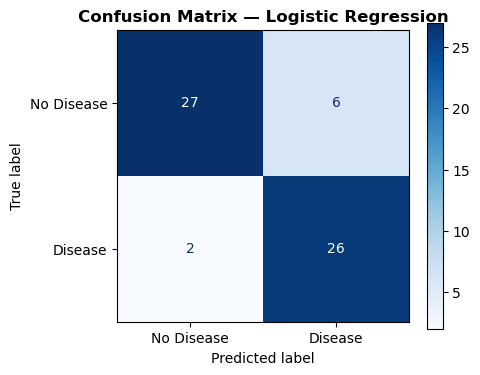

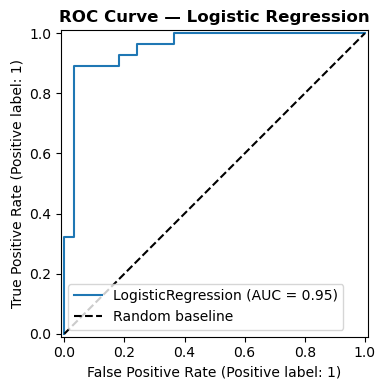

🏃 View run team07_s703_logistic_regression_baseline at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/231171a77f0c4aaeb270de227f6df9ff
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
LOGISTIC REGRESSION RESULTS
  TEST  test_accuracy            : 0.8689
  TEST  test_auc_roc             : 0.9545
  TEST  test_f1                  : 0.8667
  TEST  test_precision           : 0.8125
  TEST  test_recall              : 0.9286
  TRAIN train_accuracy           : 0.8388
  TRAIN train_auc_roc            : 0.9172
  TRAIN train_f1                 : 0.8152
  TRAIN train_precision          : 0.86
  TRAIN train_recall             : 0.7748
Run ID: 231171a77f0c4aaeb270de227f6df9ff


In [12]:
from sklearn.linear_model import LogisticRegression

run_name = f"{TEAM_ID}_{STUDENT_ID}_logistic_regression_baseline"

LR_PARAMS = {'C':1.0, 'max_iter':1000, 'solver':'lbfgs', 'random_state':RANDOM_STATE}

with mlflow.start_run(run_name=run_name) as run:

    mlflow.set_tags(COMMON_TAGS)

    mlflow.log_params({**LR_PARAMS, 'model_type':'LogisticRegression',
                       'n_features':X_train.shape[1], 'train_size':X_train.shape[0]})

    lr = LogisticRegression(**LR_PARAMS)
    lr.fit(X_train, y_train)

    metrics = evaluate_model(lr, X_train, y_train, X_test, y_test)
    mlflow.log_metrics(metrics)
    log_confusion_matrix(lr, X_test, y_test, 'Logistic Regression')
    log_roc_curve(lr, X_test, y_test, 'Logistic Regression')
    mlflow.sklearn.log_model(lr, name ='model')
    LR_RUN_ID = run.info.run_id

print('LOGISTIC REGRESSION RESULTS')
for k,v in sorted(metrics.items()):
    print(f'  {"TRAIN" if k.startswith("train") else "TEST "} {k:<25}: {v}')
print(f'Run ID: {LR_RUN_ID}')


## 5. Run 2 — Random Forest Baseline

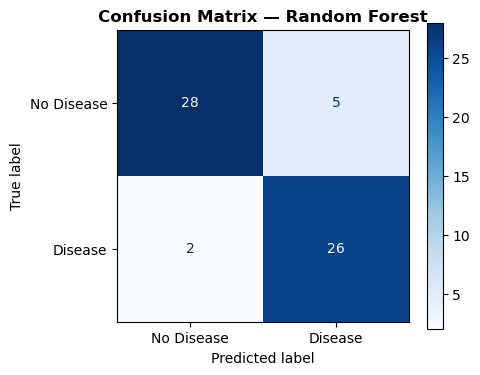

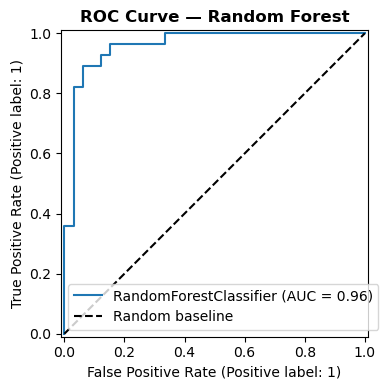

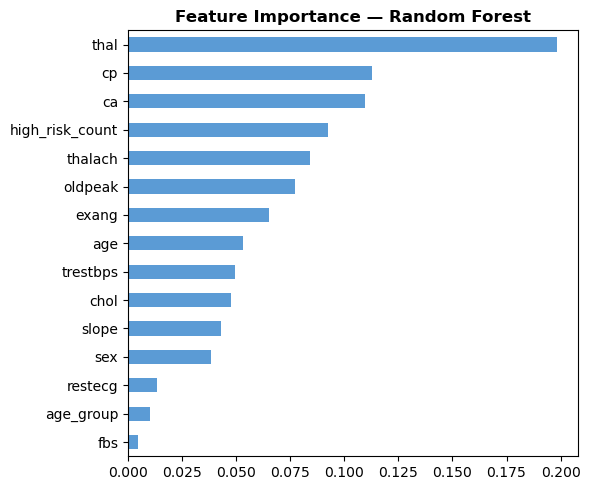

🏃 View run team07_s703_random_forest_baseline at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/612582cbb3284bf1ac58742e4ffdeed4
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
RANDOM FOREST RESULTS
  TEST  test_accuracy            : 0.8852
  TEST  test_auc_roc             : 0.96
  TEST  test_f1                  : 0.8814
  TEST  test_precision           : 0.8387
  TEST  test_recall              : 0.9286
  TRAIN train_accuracy           : 0.8967
  TRAIN train_auc_roc            : 0.9746
  TRAIN train_f1                 : 0.8837
  TRAIN train_precision          : 0.9135
  TRAIN train_recall             : 0.8559


In [13]:
from sklearn.ensemble import RandomForestClassifier

run_name = f"{TEAM_ID}_{STUDENT_ID}_random_forest_baseline"

RF_PARAMS = {'n_estimators':100,'max_depth':6,'min_samples_leaf':4,
             'class_weight':'balanced','random_state':RANDOM_STATE,'n_jobs':-1}

with mlflow.start_run(run_name=run_name) as run:

    mlflow.set_tags(COMMON_TAGS)

    mlflow.log_params({**RF_PARAMS, 'model_type':'RandomForestClassifier',
                       'n_features':X_train.shape[1], 'train_size':X_train.shape[0]})

    rf = RandomForestClassifier(**RF_PARAMS)
    rf.fit(X_train, y_train)

    metrics = evaluate_model(rf, X_train, y_train, X_test, y_test)
    mlflow.log_metrics(metrics)
    log_confusion_matrix(rf, X_test, y_test, 'Random Forest')
    log_roc_curve(rf, X_test, y_test, 'Random Forest')
    log_feature_importance(rf, X_train.columns.tolist(), 'Random Forest')
    mlflow.sklearn.log_model(rf, name ='model')
    RF_RUN_ID = run.info.run_id

print('RANDOM FOREST RESULTS')
for k,v in sorted(metrics.items()):
    print(f'  {"TRAIN" if k.startswith("train") else "TEST "} {k:<25}: {v}')


## 6. Run 3 — Hyperparameter Tuning with Nested Runs

Each hyperparameter combination is logged as a **child run** under a parent run.
This keeps the MLflow UI organised — the parent summarises the best result.


In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

param_grid = [
    {'n_estimators': 50,  'max_depth': 4, 'min_samples_leaf': 2},
    {'n_estimators':100,  'max_depth': 4, 'min_samples_leaf': 4},
    {'n_estimators':100,  'max_depth': 6, 'min_samples_leaf': 2},
    {'n_estimators':200,  'max_depth': 6, 'min_samples_leaf': 4},
    {'n_estimators':200,  'max_depth': 8, 'min_samples_leaf': 2},
]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_auc, best_model, best_params = 0, None, None

with mlflow.start_run(run_name=f"{TEAM_ID}_{STUDENT_ID}_rf_tuning_parent") as parent:

    mlflow.set_tags(COMMON_TAGS)

    mlflow.log_param('n_candidates', len(param_grid))
    mlflow.log_param('cv_folds', 5)

    for i, params in enumerate(param_grid):
        all_p = {**params, 'class_weight':'balanced', 'random_state':RANDOM_STATE}
        with mlflow.start_run(run_name=f'rf_candidate_{i+1:02d}', nested=True):
            mlflow.log_params(all_p)
            m = RandomForestClassifier(**all_p, n_jobs=-1)
            cv_scores = cross_val_score(m, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
            mlflow.log_metric('cv_auc_mean', round(cv_scores.mean(),4))
            mlflow.log_metric('cv_auc_std',  round(cv_scores.std(),4))
            m.fit(X_train, y_train)
            test_m = evaluate_model(m, X_train, y_train, X_test, y_test)
            mlflow.log_metrics(test_m)
            #log model artifact for this candidate run
            mlflow.sklearn.log_model(m, name = "model")

            print(f'Candidate {i+1}: {params} | CV AUC={cv_scores.mean():.4f} | Test AUC={test_m["test_auc_roc"]}')
            if cv_scores.mean() > best_auc:
                best_auc, best_model, best_params = cv_scores.mean(), m, all_p

    mlflow.log_metric('best_cv_auc', round(best_auc,4))
    TUNING_RUN_ID = parent.info.run_id

print(f'\nBest CV AUC : {best_auc:.4f}')
print(f'Best params : {best_params}')


Candidate 1: {'n_estimators': 50, 'max_depth': 4, 'min_samples_leaf': 2} | CV AUC=0.8797 | Test AUC=0.9632
🏃 View run rf_candidate_01 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/bbd7c65d536441d2a9e9ae88b9810820
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


Candidate 2: {'n_estimators': 100, 'max_depth': 4, 'min_samples_leaf': 4} | CV AUC=0.8921 | Test AUC=0.961
🏃 View run rf_candidate_02 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/c1619c6994194e69ae1992922bf4f73e
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


Candidate 3: {'n_estimators': 100, 'max_depth': 6, 'min_samples_leaf': 2} | CV AUC=0.8812 | Test AUC=0.9589


🏃 View run rf_candidate_03 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/14e5a3b9282748f7b13dbe71862b8ac7
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


Candidate 4: {'n_estimators': 200, 'max_depth': 6, 'min_samples_leaf': 4} | CV AUC=0.8894 | Test AUC=0.9697
🏃 View run rf_candidate_04 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/542b0cf38dd342ad99aa7f2699170ae8
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


Candidate 5: {'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 2} | CV AUC=0.8866 | Test AUC=0.9578
🏃 View run rf_candidate_05 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/0ce0b2f5c10048a99307efea3fc8b257
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


🏃 View run team07_s703_rf_tuning_parent at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/b35d3ab75b3a4d13964fd6c98d4308d2
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1

Best CV AUC : 0.8921
Best params : {'n_estimators': 100, 'max_depth': 4, 'min_samples_leaf': 4, 'class_weight': 'balanced', 'random_state': 42}


## 7. Compare Runs and Register Best Model

In [15]:
from mlflow.tracking import MlflowClient
import mlflow

client = MlflowClient()

exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)

if exp is None:
    raise ValueError(f"Experiment not found: {MLFLOW_EXPERIMENT}")

runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string="attributes.status = 'FINISHED'",
    order_by=["metrics.test_auc_roc DESC"]
)

if runs.empty:
    raise ValueError("No finished MLflow runs found yet.")

cols = [
    "tags.mlflow.runName",
    "metrics.test_auc_roc",
    "metrics.test_accuracy",
    "metrics.test_f1",
    "metrics.test_recall",
    "run_id"
]

avail = [c for c in cols if c in runs.columns]
print(runs[avail].head(8).to_string(index=False))

best_run = runs.iloc[0]
BEST_RUN_ID = best_run["run_id"]
BEST_AUC = best_run.get("metrics.test_auc_roc", 0)
BEST_RUN_NAME = best_run.get("tags.mlflow.runName", "unknown")

print(f"\nBest run: {BEST_RUN_NAME} | AUC={BEST_AUC:.4f}")

                     tags.mlflow.runName  metrics.test_auc_roc  metrics.test_accuracy  metrics.test_f1  metrics.test_recall                           run_id
                         rf_candidate_04                0.9697                 0.8852           0.8814               0.9286 542b0cf38dd342ad99aa7f2699170ae8
                         rf_candidate_01                0.9632                 0.8852           0.8814               0.9286 bbd7c65d536441d2a9e9ae88b9810820
                         rf_candidate_02                0.9610                 0.8852           0.8814               0.9286 c1619c6994194e69ae1992922bf4f73e
      team07_s703_random_forest_baseline                0.9600                 0.8852           0.8814               0.9286 612582cbb3284bf1ac58742e4ffdeed4
                         rf_candidate_03                0.9589                 0.8689           0.8667               0.9286 14e5a3b9282748f7b13dbe71862b8ac7
                         rf_candidate_05                0.

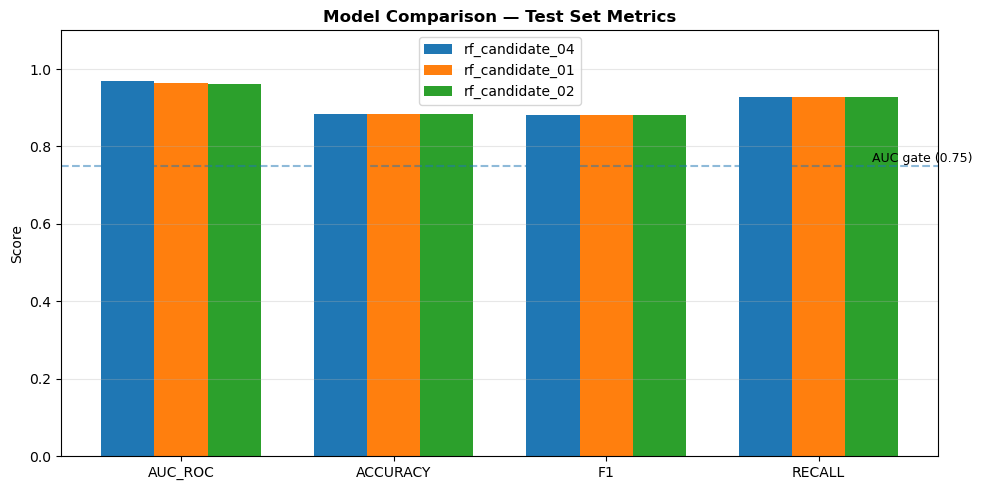

In [16]:
# Visual comparison of top completed runs in the current experiment.
fig, ax = plt.subplots(figsize=(10,5))

metric_cols = [
    'metrics.test_auc_roc',
    'metrics.test_accuracy',
    'metrics.test_f1',
    'metrics.test_recall'
]
avail_m = [c for c in metric_cols if c in runs.columns]

# Use the top 3 finished runs by AUC.
top_runs = runs.head(3)

labels = [c.replace('metrics.test_','').upper() for c in avail_m]
x = np.arange(len(labels))
w = 0.25

for idx,(_, row) in enumerate(top_runs.iterrows()):
    vals = [row.get(m,0) for m in avail_m]
    ax.bar(
        x + idx*w,
        vals,
        w,
        label=row.get('tags.mlflow.runName', f'run{idx}')
    )

ax.set_xticks(x+w)
ax.set_xticklabels(labels)
ax.set_ylim(0,1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Metrics', fontweight='bold')
ax.axhline(0.75, linestyle='--', alpha=0.5)
ax.text(len(labels)-0.5, 0.76, 'AUC gate (0.75)', fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [17]:
# ==========================================================
# Quality Gate and Best Model Selection
# ==========================================================

QUALITY_GATE = 0.75

print("=" * 60)
print("QUALITY GATE")
print("=" * 60)

if BEST_AUC < QUALITY_GATE:

    print(f"❌ Quality gate FAILED")
    print(f"Best AUC : {BEST_AUC:.4f}")
    print(f"Required : {QUALITY_GATE:.2f}")
    print("\nReview feature engineering or hyperparameters before proceeding.")

    BEST_MODEL_URI = None

else:

    print(f"✅ Quality gate PASSED")
    print(f"Best AUC : {BEST_AUC:.4f}")

    # Export information for Notebook 03
    BEST_MODEL_URI = f"runs:/{BEST_RUN_ID}/model"

    print("\nBest MLflow Run")
    print("-" * 60)
    print(f"Run Name   : {BEST_RUN_NAME}")
    print(f"Run ID     : {BEST_RUN_ID}")
    print(f"Model URI  : {BEST_MODEL_URI}")
    print(f"Best AUC   : {BEST_AUC:.4f}")

print("=" * 60)


QUALITY GATE
✅ Quality gate PASSED
Best AUC : 0.9697

Best MLflow Run
------------------------------------------------------------
Run Name   : rf_candidate_04
Run ID     : 542b0cf38dd342ad99aa7f2699170ae8
Model URI  : runs:/542b0cf38dd342ad99aa7f2699170ae8/model
Best AUC   : 0.9697


In [18]:
# ==========================================================
# Notebook 03 Inputs
# ==========================================================

print("\nCopy these values into Notebook 03 if required:\n")

print(f'BEST_RUN_ID    = "{BEST_RUN_ID}"')

if BEST_MODEL_URI is not None:
    print(f'BEST_MODEL_URI = "{BEST_MODEL_URI}"')

print(f"BEST_AUC       = {BEST_AUC:.4f}")
print(f'BEST_RUN_NAME  = "{BEST_RUN_NAME}"')


Copy these values into Notebook 03 if required:

BEST_RUN_ID    = "542b0cf38dd342ad99aa7f2699170ae8"
BEST_MODEL_URI = "runs:/542b0cf38dd342ad99aa7f2699170ae8/model"
BEST_AUC       = 0.9697
BEST_RUN_NAME  = "rf_candidate_04"


In [19]:
# Write to JSON file so Notebook 03 can read it.
import json

best_model_info = {
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "project_name": PROJECT_NAME,
    "best_run_id": BEST_RUN_ID,
    "best_run_name": BEST_RUN_NAME,
    "best_auc": float(BEST_AUC),
    "best_model_uri": BEST_MODEL_URI,
    "mlflow_tracking_uri": MLFLOW_APP_ARN,
    "mlflow_experiment": MLFLOW_EXPERIMENT,
    "tracking_backend": "sagemaker_mlflow_app",
    "mlflow_app_team_tag": TEAM_ID,
}

with open("best_model.json", "w") as f:
    json.dump(best_model_info, f, indent=4)

print("Saved best model information to best_model.json")
print(json.dumps(best_model_info, indent=2))


Saved best model information to best_model.json
{
  "team_id": "team07",
  "student_id": "s703",
  "project_name": "heart-disease",
  "best_run_id": "542b0cf38dd342ad99aa7f2699170ae8",
  "best_run_name": "rf_candidate_04",
  "best_auc": 0.9697,
  "best_model_uri": "runs:/542b0cf38dd342ad99aa7f2699170ae8/model",
  "mlflow_tracking_uri": "arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PVSI6X27672O",
  "mlflow_experiment": "ITI113/team07/Experiment1",
  "tracking_backend": "sagemaker_mlflow_app",
  "mlflow_app_team_tag": "team07"
}


In [20]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
artifacts = client.list_artifacts(BEST_RUN_ID)

for a in artifacts:
    print(a.path, a.is_dir)

In [21]:
# Load best model directly from the best MLflow run and test inference
loaded = mlflow.sklearn.load_model(BEST_MODEL_URI)

sample = X_test.head(5)
preds = loaded.predict(sample)
probas = loaded.predict_proba(sample)[:, 1]

results = pd.DataFrame({
    "actual": y_test.head(5).values,
    "predicted": preds,
    "probability": probas.round(3),
    "correct": preds == y_test.head(5).values
})

print("Sample predictions from best MLflow run model:")
print(results.to_string(index=False))

Sample predictions from best MLflow run model:
 actual  predicted  probability  correct
      0          0        0.275     True
      0          1        0.603    False
      0          0        0.104     True
      0          0        0.051     True
      0          0        0.386     True


In [22]:
print("=" * 55)
print("NOTEBOOK 02 COMPLETE")
print("=" * 55)
print(f"Experiment : {MLFLOW_EXPERIMENT}")
print(f"MLflow App : {MLFLOW_APP_ARN}")
print(f"Best model : {BEST_RUN_NAME} | AUC={BEST_AUC:.4f}")
print(f"Best run ID: {BEST_RUN_ID}")
print(f"Model URI  : {BEST_MODEL_URI}")
print()
print("Next: Notebook 03 — run the SageMaker Pipeline using the same team S3 folder.")
print("For AWS-native tracking, use the same SageMaker MLflow App ARN in later notebooks.")


NOTEBOOK 02 COMPLETE
Experiment : ITI113/team07/Experiment1
MLflow App : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PVSI6X27672O
Best model : rf_candidate_04 | AUC=0.9697
Best run ID: 542b0cf38dd342ad99aa7f2699170ae8
Model URI  : runs:/542b0cf38dd342ad99aa7f2699170ae8/model

Next: Notebook 03 — run the SageMaker Pipeline using the same team S3 folder.
For AWS-native tracking, use the same SageMaker MLflow App ARN in later notebooks.


---
## Checklist before Notebook 03

- [ ] Notebook 01A created or reused the SageMaker MLflow App with TeamId tag
- [ ] `mlflow_app_config_<team_id>.json` or `mlflow_app_config_<team_id>_<student_id>.json` is available, or `DEFAULT_MLFLOW_APP_ARN` was verified
- [ ] SageMaker MLflow App connection working
- [ ] MLflow App tag `TeamId` matches notebook `TEAM_ID`
- [ ] Logistic Regression baseline logged to SageMaker MLflow App
- [ ] Random Forest baseline logged to SageMaker MLflow App
- [ ] Hyperparameter tuning nested runs visible in the SageMaker MLflow UI
- [ ] Quality gate passed (Best Test AUC ≥ 0.75)
- [ ] Best MLflow run identified
- [ ] BEST_RUN_ID recorded
- [ ] BEST_MODEL_URI generated successfully
- [ ] Able to load the best model from the MLflow Run URI and make predictions
- [ ] `best_model.json` generated with MLflow App tracking details

→ Continue to Notebook 03 to orchestrate training, model registration and deployment using SageMaker Pipelines.


## Download model if needed

In [23]:
# ============================================================
# Find MLflow model URI, load model, and download model artifact
# For SageMaker MLflow App / Serverless MLflow
# ============================================================

import os
import json
from pathlib import Path

import mlflow
import mlflow.sklearn


# ------------------------------------------------------------
# 1. Load best model information saved by Notebook 02
# ------------------------------------------------------------

BEST_MODEL_JSON = "best_model.json"

if not os.path.exists(BEST_MODEL_JSON):
    raise FileNotFoundError(
        f"{BEST_MODEL_JSON} not found. "
        "Run the model selection cell first."
    )

with open(BEST_MODEL_JSON, "r") as f:
    best_model_info = json.load(f)

print("Best model information:")
print(json.dumps(best_model_info, indent=2))


# ------------------------------------------------------------
# 2. Set MLflow tracking URI
# ------------------------------------------------------------

mlflow_tracking_uri = best_model_info["mlflow_tracking_uri"]
best_model_uri = best_model_info["best_model_uri"]
best_run_id = best_model_info["best_run_id"]

mlflow.set_tracking_uri(mlflow_tracking_uri)

print("\nMLflow tracking URI:")
print(mlflow_tracking_uri)

print("\nBest run ID:")
print(best_run_id)

print("\nBest model URI:")
print(best_model_uri)


# ------------------------------------------------------------
# 3. Load the model directly from MLflow
# ------------------------------------------------------------

loaded_model = mlflow.sklearn.load_model(best_model_uri)

print("\nLoaded model type:")
print(type(loaded_model))


# ------------------------------------------------------------
# 4. Download the MLflow model artifact folder locally
# ------------------------------------------------------------

download_dir = Path("downloaded_mlflow_models")
download_dir.mkdir(parents=True, exist_ok=True)

local_model_path = mlflow.artifacts.download_artifacts(
    artifact_uri=best_model_uri,
    dst_path=str(download_dir)
)

print("\nDownloaded model folder:")
print(local_model_path)


# ------------------------------------------------------------
# 5. List downloaded model files
# ------------------------------------------------------------

print("\nDownloaded files:")

for root, dirs, files in os.walk(local_model_path):
    level = root.replace(local_model_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        file_path = os.path.join(root, file)
        size_bytes = os.path.getsize(file_path)
        print(f"{indent}  {file}  ({size_bytes} bytes)")


# ------------------------------------------------------------
# 6. Optional quick prediction test
# ------------------------------------------------------------
# Uncomment if X_test exists in your notebook.
#
# sample = X_test.head(5)
# predictions = loaded_model.predict(sample)
# print("\nSample predictions:")
# print(predictions)

Best model information:
{
  "team_id": "team07",
  "student_id": "s703",
  "project_name": "heart-disease",
  "best_run_id": "542b0cf38dd342ad99aa7f2699170ae8",
  "best_run_name": "rf_candidate_04",
  "best_auc": 0.9697,
  "best_model_uri": "runs:/542b0cf38dd342ad99aa7f2699170ae8/model",
  "mlflow_tracking_uri": "arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PVSI6X27672O",
  "mlflow_experiment": "ITI113/team07/Experiment1",
  "tracking_backend": "sagemaker_mlflow_app",
  "mlflow_app_team_tag": "team07"
}

MLflow tracking URI:
arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PVSI6X27672O

Best run ID:
542b0cf38dd342ad99aa7f2699170ae8

Best model URI:
runs:/542b0cf38dd342ad99aa7f2699170ae8/model



Loaded model type:
<class 'sklearn.ensemble._forest.RandomForestClassifier'>



Downloaded model folder:
/home/sagemaker-user/test-sample-scripts/downloaded_mlflow_models/model/

Downloaded files:
/
  MLmodel  (742 bytes)
  conda.yaml  (350 bytes)
  python_env.yaml  (123 bytes)
  requirements.txt  (200 bytes)
  model.skops  (4022997 bytes)
  registered_model_meta  (37 bytes)
